### DOE analysis on /theta (transconjugant rate score)

In [1]:
import pandas as pd 
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from numpy.random import default_rng
import os
import arviz as az

# Import functions
from cmdstanpy import CmdStanModel
from tensorflow_probability.substrates import numpy as tfp
tfd = tfp.distributions


import cmdstanpy
import os
from pathlib import Path

import os, sys
from pathlib import Path
def set_project_root():
        
    # Find and navigate to Progetto_Bayesian_Statistics
    current = Path.cwd()

    # Check if we're already there
    if current.name == 'Progetto_Bayesian_Statistics':
        print(f"Already in project root: {current}")
    else:
        # Search up to parent directories
        for parent in [current] + list(current.parents):
            if parent.name == 'Progetto_Bayesian_Statistics':
                os.chdir(parent)
                print(f"Changed to: {parent}")
                break
        else:
            raise FileNotFoundError("Progetto_Bayesian_Statistics folder not found")

    # Verify
    assert Path('src').exists(), "src/ folder not found"
    print(f"Current directory: {os.getcwd()}")
    print(f"Contents: {os.listdir()}")


    # Create ./stan folder if does not exists
    STAN_PATH = "./src/stan_models/"
    print(cmdstanpy.cmdstan_path())
    return STAN_PATH

STAN_PATH = set_project_root()
print("cwd:", os.getcwd())
print("first sys.path entries:")
for p in sys.path[:5]:
    print("  ", p)

print("project root guess:", Path().resolve())
print("exists ./src ?", (Path().resolve() / "src").exists())

from src.utils.utils import *

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Changed to: /Users/sararedaelli/Desktop/Progetto_Bayesian_Statistics
Current directory: /Users/sararedaelli/Desktop/Progetto_Bayesian_Statistics
Contents: ['materials', '.DS_Store', 'requirements.txt', 'README.md', 'results', '.gitignore', 'requirements.bk.txt', '.git', 'results1', 'data', 'src']
/Users/sararedaelli/.cmdstan/cmdstan-2.37.0
cwd: /Users/sararedaelli/Desktop/Progetto_Bayesian_Statistics
first sys.path entries:
   /Library/Frameworks/Python.framework/Versions/3.13/lib/python313.zip
   /Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13
   /Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/lib-dynload
   
   /Users/sararedaelli/Library/Python/3.13/lib/python/site-packages
project root guess: /Users/sararedaelli/Desktop/Progetto_Bayesian_Statistics
exists ./src ? True


In [2]:
data, data_donors = transform_data()
glm_data, X_D = get_glm_data(data, data_donors)

[1 2 3 4 5 6 7 8]
[1 2 3 4 5 6 7 8]


/Users/sararedaelli/Desktop/Progetto_Bayesian_Statistics/src/utils/utils.py:70: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data['Control'] = data['Control'].replace({'Yes': 1, 'No': 0})


In [3]:
model_names = [("ab_baseline_simple_poi.stan", {}), ("ab_lasso.stan", {}), ("ab_horseshoe.stan", {}), ("ab_regularized_horseshoe.stan", {"p0": 2}), ("ab_r2d2.stan", {"R2_mean": 0.5,"R2_prec": 2.0, "cons_D2": 0.5})]

models = {}
for key in model_names:
    glm = CmdStanModel(stan_file=f"{STAN_PATH}/{key[0]}")
    for x in X_D:
        models[(key[0], tuple(key[1].items()), x)] = {"model": glm, "X": X_D[x]}
        new_data = glm_data.copy()
        new_data.update({"X": X_D[x], "p": X_D[x].shape[1]})
        new_data.update(key[1])
        models[(key[0], tuple(key[1].items()), x)]["data"] = new_data

In [4]:
import os
for key in models:
    filename = f"{'_'.join(str(k) for k in key)}.nc"
    models[key]["az"] = az.from_netcdf(f"./results/ab/{filename}")

##### Reconstruct the posterior mean rate per observation

In [39]:
import numpy as np
import xarray as xr

def get_posterior_rate_means(idata, X, idx_experiment, idx_experiment_replica, one_based=True):
    exp_idx = np.asarray(idx_experiment)
    rep_idx = np.asarray(idx_experiment_replica)

    # Stan indices are usually 1..I, 1..J
    if one_based:
        exp_idx = exp_idx - 1
        rep_idx = rep_idx - 1


    post = idata.posterior
    beta = post["beta"]
    b_re = post["beta_random"]

    beta_np = beta.stack(sample=("chain", "draw")).values      # (sample, p)
    b_re_np = b_re.stack(sample=("chain", "draw")).values      # (sample, I, J)
    
    X_np    = np.asarray(X)                                   # (obs, p)
    beta_np = beta_np.T                       # (24000, 4)
    b_re_np  = np.transpose(b_re_np, (2,0,1)) # (24000, 8, 3)


    # fixed part: (sample, obs)
    eta_np = beta_np @ X_np.T

    # random intercept per obs: (sample, obs)
    # advanced indexing: exp_idx and rep_idx are (obs,)
    b_obs_np = b_re_np[:, exp_idx, rep_idx]

    # combine + exp
    mu_np = np.exp(eta_np + b_obs_np)

    # posterior mean per obs: (obs,)
    rate_mean = mu_np.mean(axis=0)

    #compute log rate mean
    log_rate_mean = np.log(rate_mean)

    return log_rate_mean


In [19]:
models.keys()
models[("ab_baseline_simple_poi.stan", tuple({}.items()), "X")]["X"].shape

(378, 4)

In [40]:
#apply function to the simple model with X simple
get_posterior_rate_means(models[("ab_baseline_simple_poi.stan", tuple({}.items()), "X")]["az"], 
                         models[("ab_baseline_simple_poi.stan", tuple({}.items()), "X")]["X"], glm_data["idx_experiment"], glm_data["idx_experiment_replica"])

array([ -9.61302869,  -9.61302869,  -9.61302869,  -9.61302869,
        -9.61302869,  -9.61302869,  -9.61364136,  -9.61364136,
        -9.61364136,  -9.61364136,  -9.61364136,  -9.61364136,
       -10.93331473, -10.93331473, -10.93331473, -10.93331473,
       -10.93331473, -10.93331473, -10.93331473, -10.93331473,
       -10.93331473, -10.93392182, -10.93392182, -10.93392182,
       -10.93392182, -10.93392182, -10.93392182, -10.93392182,
       -10.93392182, -10.93392182, -10.5386652 , -10.5386652 ,
       -10.5386652 , -10.5386652 , -10.5386652 , -10.5386652 ,
       -10.5386652 , -10.5386652 , -10.5386652 , -10.54352934,
       -10.54352934, -10.54352934, -10.54352934, -10.54352934,
       -10.54352934, -10.54352934, -10.54352934, -10.54352934,
       -10.69028502, -10.69028502, -10.69028502, -10.69028502,
       -10.69028502, -10.69028502, -10.69028502, -10.69028502,
       -10.69028502, -10.69513064, -10.69513064, -10.69513064,
       -10.69513064, -10.69513064, -10.69513064, -10.69

In [41]:
data_donors.head()

,Idx Experiment,Idx Replica Experiment,Diluition,IBU,DMSO,Temp,Count
0,1,1,-6,6.25,0,28,51
1,1,2,-6,6.25,0,28,48
2,1,3,-6,6.25,0,28,50
3,1,1,-7,6.25,0,28,7
4,1,2,-7,6.25,0,28,3


<Axes: >

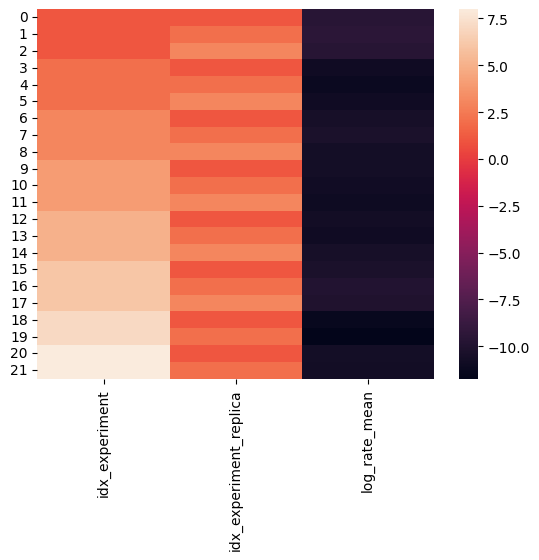

In [50]:
#heatmap of the mean log rate per experiment and replica
import seaborn as sns
import matplotlib.pyplot as plt

df=pd.DataFrame({
    "idx_experiment": glm_data["idx_experiment"],
    "idx_experiment_replica": glm_data["idx_experiment_replica"],
    "log_rate_mean": get_posterior_rate_means(models[("ab_baseline_simple_poi.stan", tuple({}.items()), "X")]["az"], 
                         models[("ab_baseline_simple_poi.stan", tuple({}.items()), "X")]["X"], glm_data["idx_experiment"], glm_data["idx_experiment_replica"])
})  
#mean log rate per experiment and replica
sns.heatmap(df.groupby(["idx_experiment", "idx_experiment_replica"])["log_rate_mean"].mean().reset_index())





### Posterior mean dati

In [ ]:
#log rate from the data 
real_counts=glm_data["Y"]/glm_data["rho_trasc"]
donor_mean_experiment = data_donors.groupby(["Idx Experiment","Idx Replica Experiment"])["Count"].mean().reset_index()
donor_mean_experiment.head()


,Idx Experiment,Idx Replica Experiment,Count
0,1,1,20.000000
1,1,2,17.000000
2,1,3,18.666667
3,2,1,40.333333
4,2,2,39.666667
